# 8 &middot; Weak Gravitational Lensing

Weak lensing distorts the images of distant galaxies as their light passes foreground matter.
The **convergence** $\kappa$ measures the projected mass along the line of sight (weighted by a
lensing efficiency kernel), and the **shear** $\gamma=(\gamma_1,\gamma_2)$ is the
ellipticity distortion derived from it.

This notebook turns a spherical PM lightcone (from [notebook 7](07-Advanced-PM.ipynb)) into:

1. **convergence** maps via two methods —

   | Method | Function | JAX | Accuracy |
   |--------|----------|-----|----------|
   | Born approximation | `jfli.born` | yes (differentiable) | first order |
   | Ray-tracing | `jfli.raytrace` | no (dorian, post-Born) | full distortion matrix |

2. **shear** maps via spherical Kaiser-Squires (`kappa.get_shear()`), and
3. **catalogs**: saving convergence and shear to Parquet for later analysis (e.g.
   [notebook 9](09-External-Catalog.ipynb)).

This notebook runs **distributed across 8 devices**: a single `field_sharding` argument on
`gaussian_initial_conditions` partitions the initial field, and every downstream operation
(`lpt`, `nbody`, lightcone painting) respects it automatically &mdash; exactly as in
[notebook 4](../1-introduction-and-basics/04-Distributed-PM.ipynb). The lensing pipeline code
below is identical to the single-device case.

## Setup

You can simulate multiple devices on a single CPU by setting the `XLA_FLAGS` environment variable to include `--xla_force_host_platform_device_count=8` (or however many devices you want). This forces JAX to treat the CPU as if it had multiple devices, allowing you to test distributed computations without needing actual GPUs.

The `--xla_force_host_platform_device_count` flag must be set **before** JAX initialises its backend (before the first `import jax`).

```
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=8"
os.environ["JAX_PLATFORMS"] = "cpu"
```

On real GPUs, drop both variables &mdash; JAX discovers the devices automatically.

In [ ]:
import contextlib
import io
import logging

import jax
import jax.numpy as jnp
import jax_cosmo as jc
import jax_fli as jfli
import matplotlib.pyplot as plt
import numpy as np
from jax.sharding import AxisType, NamedSharding
from jax.sharding import PartitionSpec as P

jax.config.update("jax_enable_x64", False)
print(f"Number of devices: {jax.device_count()}")
print(jax.devices())

## Device mesh and sharding

A `Mesh` maps physical devices onto named axes; a `PartitionSpec` then says which array
dimensions are split over which mesh axes. The `jaxpm` distributed backend expects a **2-D
mesh** so that the first two spatial dimensions of the 3-D field are each partitioned.

In [ ]:
mesh = jax.make_mesh((8, 1), ("x", "y"), axis_types=(AxisType.Auto, AxisType.Auto))
sharding = NamedSharding(mesh, P("x", "y"))
print(f"Mesh shape     : {mesh.shape}")
print(f"Partition spec : {sharding.spec}")

## A spherical lightcone

We build an 8-shell HEALPix lightcone with the `OnionTiler` kernel (`drift_on_lightcone=True`
so particles are drifted onto the lightcone for lensing). Passing `field_sharding` (and a
`halo_size` of ghost cells for the stencil/FFT exchange) to `gaussian_initial_conditions` is the
only distributed-specific change &mdash; the returned field carries the sharding, so `lpt` and
`nbody` run partitioned across the mesh with no further edits.

In [ ]:
key = jax.random.PRNGKey(0)
mesh_size = (1000, 1000, 1000)
box_size = (3000.0, 3000.0, 3000.0)
halo_size = (32, 32)
nside = 1024
nb_shells = 8
cosmo = jc.Planck18()

initial_field = jfli.gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    cosmo=cosmo,
    nside=nside,
    field_sharding=sharding,
    halo_size=halo_size,
)
print(f"initial field shape    : {initial_field.array.shape}")
print(f"initial field sharding : {initial_field.array.sharding}")

dx, p = jfli.lpt(cosmo, initial_field, ts=0.1, order=1)
solver = jfli.DoubleKickDrift(
    interp_kernel=jfli.OnionTiler(
        painting=jfli.PaintingOptions(target="spherical", scheme="ngp"), drift_on_lightcone=True
    ),
    t0=0.1,
    t1=1.0,
    n_steps=16,
)
lightcone = jfli.nbody(cosmo, dx, p, nb_shells=nb_shells, solver=solver)
print(f"lightcone: {lightcone.shape}, scale factors: {np.asarray(lightcone.scale_factors).round(2)}")

## Source redshift distributions $n(z)$

Lensing is computed for a galaxy population with a redshift distribution $n(z)$. We use three
tomographic bins from a Stage-3 forecast (`jfli.io.get_stage3_nz_shear`).

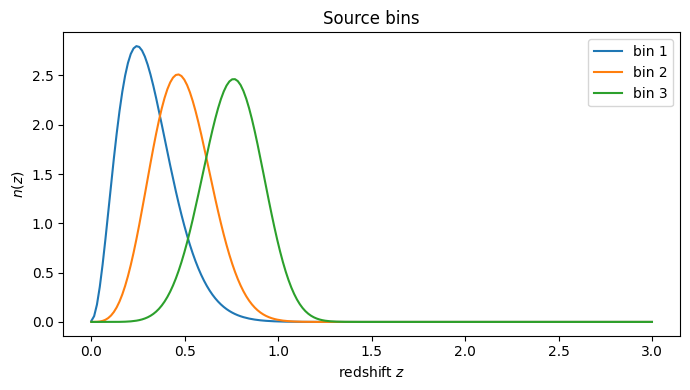

In [3]:
nz_sources = jfli.io.get_stage3_nz_shear()[:3]

z = jnp.linspace(0.0, 3.0, 200)
plt.figure(figsize=(7, 4))
for i, nz in enumerate(nz_sources):
    plt.plot(z, nz(z), label=f"bin {i + 1}")
plt.xlabel("redshift $z$")
plt.ylabel("$n(z)$")
plt.legend()
plt.title("Source bins")
plt.tight_layout()
plt.show()

## Born approximation

`jfli.born` integrates the weighted projected density along straight (unperturbed) light paths.
It is fully JAX — `jit`/`grad`-able — and returns a `SphericalKappaField` (one map per source
bin).

SphericalKappaField  shape=(3, 49152)


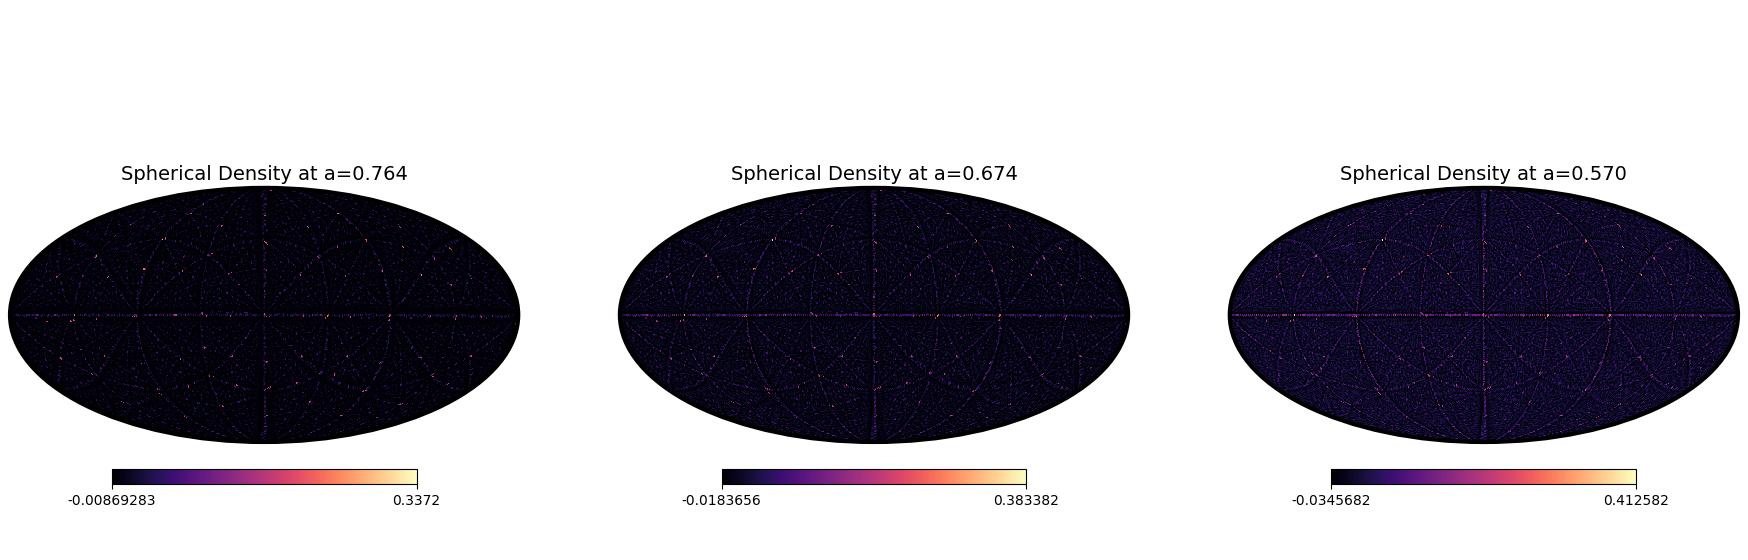

In [4]:
kappa_born = jfli.born(cosmo, lightcone, nz_shear=nz_sources)
print(f"{type(kappa_born).__name__}  shape={kappa_born.shape}")
kappa_born.apply_fn(jnp.log1p).show(ncols=3)

## Convergence &rarr; shear (Kaiser-Squires)

`SphericalKappaField.get_shear()` applies the spherical Kaiser-Squires relation, converting each
$\kappa$ map into a pure-E-mode shear field $(\gamma_1, \gamma_2)$ — a `SphericalShearField` of
shape `(n_bins, 2, npix)`.

SphericalShearField  shape=(3, 2, 49152)  (bins, [g1,g2], npix)


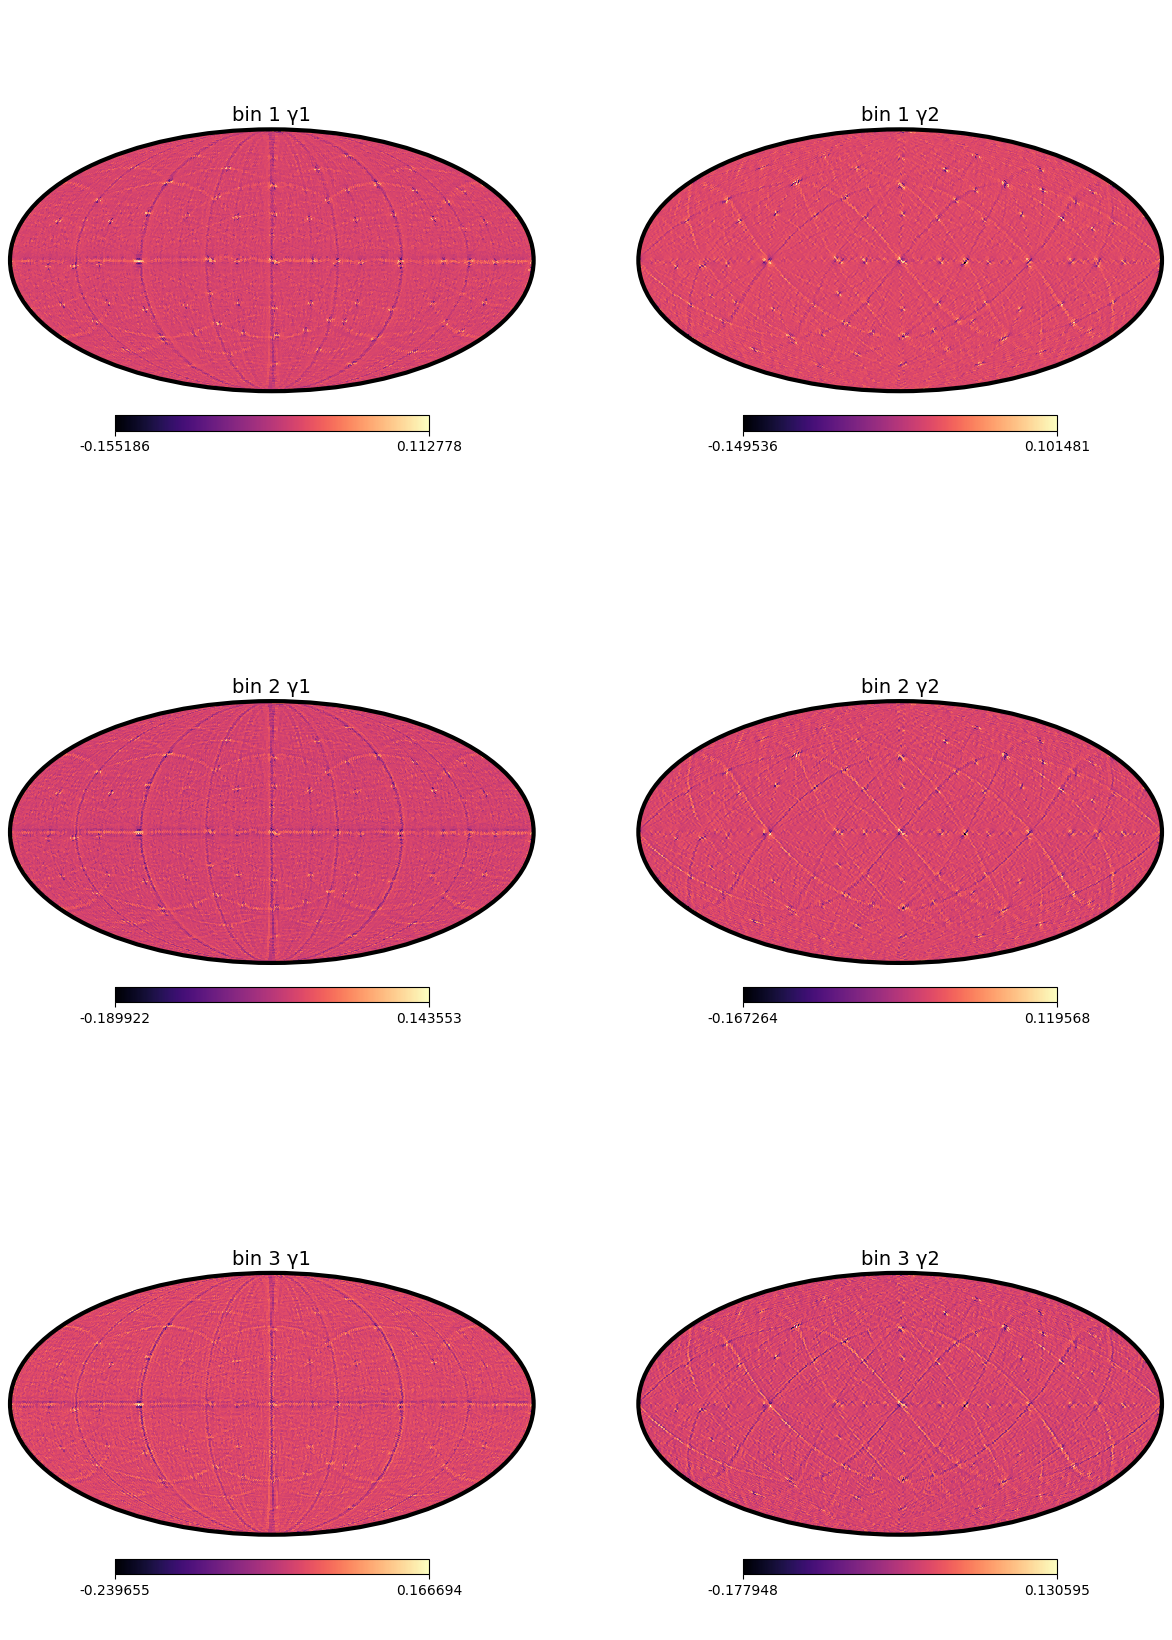

In [5]:
shear = kappa_born.get_shear()
print(f"{type(shear).__name__}  shape={shear.shape}  (bins, [g1,g2], npix)")
shear.apply_fn(jnp.log1p).show(ncols=2, titles=[f"bin {b + 1} γ{c}" for b in range(shear.shape[0]) for c in (1, 2)])

## Ray-tracing (post-Born)

`jfli.raytrace` propagates the full distortion matrix through each lens plane (via **dorian**),
capturing lens-lens coupling that Born misses. It is **not** JAX-compatible. We ask for both the
ray-traced and dorian-Born maps and compare to the difference (the dorian logs are voluminous, so
we silence them).

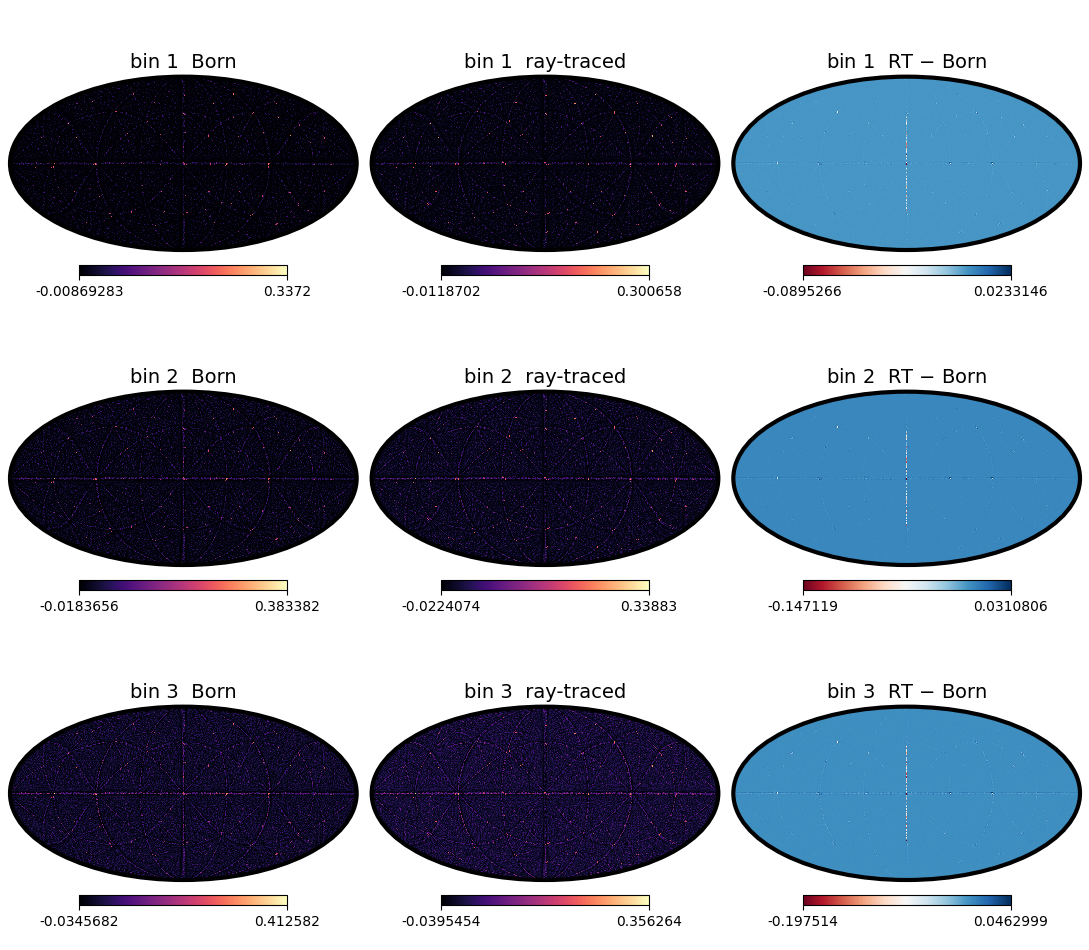

In [6]:
logging.getLogger().setLevel(logging.ERROR)
with contextlib.redirect_stdout(io.StringIO()):
    kappa_rt, kappa_born_dorian = jfli.raytrace(cosmo, lightcone, nz_shear=nz_sources, born=True, raytrace=True)

n = kappa_born.shape[0]
fig, axs = plt.subplots(n, 3, figsize=(11, 3.2 * n))
kappa_born.apply_fn(jnp.log1p).plot(ax=axs[:, 0], titles=[f"bin {i + 1}  Born" for i in range(n)])
kappa_rt.apply_fn(jnp.log1p).plot(ax=axs[:, 1], titles=[f"bin {i + 1}  ray-traced" for i in range(n)])
(kappa_rt - kappa_born_dorian).plot(ax=axs[:, 2], titles=[f"bin {i + 1}  RT $-$ Born" for i in range(n)], cmap="RdBu")
plt.tight_layout()
plt.show()

## Convergence power spectra vs theory

Compare the measured $C_\ell^{\kappa\kappa}$ against the `weak_lensing` Halofit prediction.

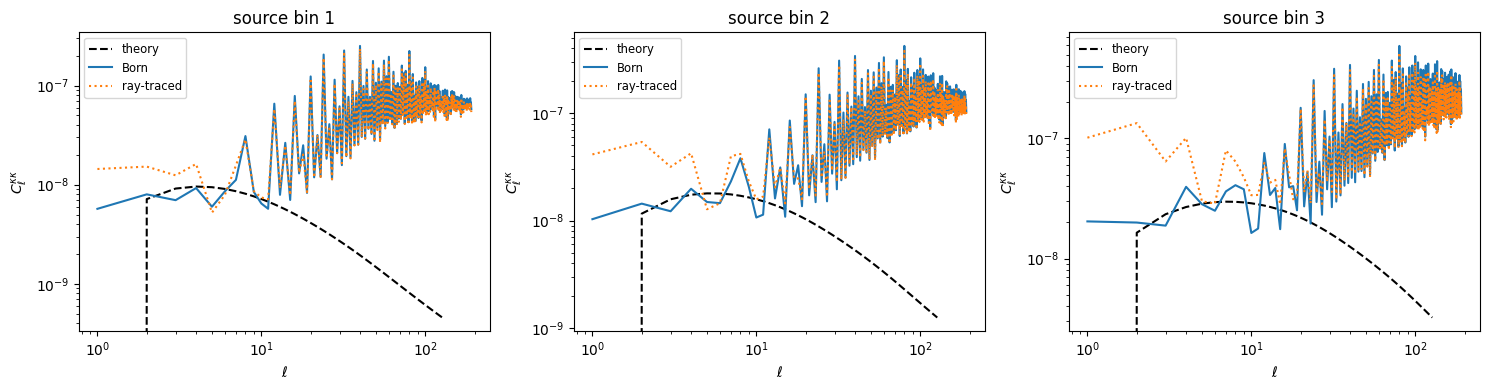

In [7]:
LMAX = 2 * nside
ells = jnp.arange(LMAX)
theory_cl = jfli.compute_theory_cl(
    cosmo, ell=ells, z_source=nz_sources, probe_type="weak_lensing", nonlinear_fn=jc.power.halofit, cross=False
)
cl_born = kappa_born.angular_cl(method="healpy")
cl_rt = kappa_rt.angular_cl(method="healpy")

th = np.asarray(theory_cl.array)
cb = np.asarray(cl_born.array)
cr = np.asarray(cl_rt.array)
L = np.arange(1, cb.shape[-1])
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
for i in range(n):
    axes[i].loglog(np.arange(LMAX)[1:], th[i, 1:], "k--", label="theory")
    axes[i].loglog(L, cb[i, 1:], color="C0", label="Born")
    axes[i].loglog(L, cr[i, 1:], color="C1", ls=":", label="ray-traced")
    axes[i].set_title(f"source bin {i + 1}")
    axes[i].set_xlabel(r"$\ell$")
    axes[i].set_ylabel(r"$C_\ell^{\kappa\kappa}$")
    axes[i].legend(fontsize="small")
plt.tight_layout()
plt.show()

## Saving convergence and shear catalogs

Both the convergence and the shear are ordinary fields, so they serialise with `jfli.io.Catalog`
just like the density maps in [notebook 1](../1-introduction-and-basics/01-basics.ipynb).

In [8]:
kappa_cat = jfli.io.Catalog(field=kappa_born, cosmology=cosmo)
kappa_cat.to_parquet("lensing_kappa.parquet")
shear_cat = jfli.io.Catalog(field=shear, cosmology=cosmo)
shear_cat.to_parquet("lensing_shear.parquet")

kappa_reloaded = jfli.io.Catalog.from_parquet("lensing_kappa.parquet")
shear_reloaded = jfli.io.Catalog.from_parquet("lensing_shear.parquet")
print("convergence ->", type(kappa_reloaded.field[0]).__name__, kappa_reloaded.field[0].shape)
print("shear       ->", type(shear_reloaded.field[0]).__name__, shear_reloaded.field[0].shape)

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

convergence -> SphericalKappaField (3, 49152)
shear       -> SphericalShearField (3, 2, 49152)


## Next

[09 &middot; External Catalogs](09-External-Catalog.ipynb) loads convergence/density maps produced
by other codes (CosmoGrid, GowerStreet) into the same `Catalog` containers.